# Проектная лабораторная работа
## Визуализация данных

### Проект:
**Netflix Movies and TV Shows Analysis**

**Студент:** Байдалин Алим

---

### Цель проекта

Провести исследовательский анализ (EDA) датасета Netflix Movies and TV Shows, выполнить очистку данных, выявить закономерности и подготовить данные для последующей визуализации и машинного обучения.

In [2]:
from google.colab import files

uploaded = files.upload()


Saving netflix_titles.csv to netflix_titles.csv


In [3]:
# Импорт библиотек

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# 1. Загрузка датасета

На данном этапе загружается датасет Netflix Movies and TV Shows для дальнейшего анализа.

In [4]:
# Загрузка датасета

df = pd.read_csv("netflix_titles.csv")

print("Датасет успешно загружен!")

Датасет успешно загружен!


# 2. Первичное знакомство с данными

Изучим первые строки датасета, чтобы понять его структуру и содержимое.

In [7]:
# Первые пять строк

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


# 3. Изучение структуры датасета

Перед анализом необходимо определить размер датасета, типы данных и основную информацию о признаках.

In [8]:
# Размер датасета

print("Количество строк и столбцов:")
df.shape

Количество строк и столбцов:


(8807, 12)

In [9]:
# Общая информация

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
# Названия всех столбцов

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### Вывод

На данном этапе была изучена структура датасета: определено количество строк и столбцов, просмотрены названия признаков и их типы данных.

# 4. Проверка пропущенных значений

Определим количество пропусков в каждом столбце датасета.

In [12]:
# Проверка пропусков

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [13]:
# Процент пропущенных значений

(df.isnull().sum() / len(df) * 100).round(2)

,0
show_id,0.00
type,0.00
title,0.00
director,29.91
cast,9.37
country,9.44
date_added,0.11
release_year,0.00
rating,0.05
duration,0.03


### Вывод

Полученные результаты позволяют определить признаки, требующие очистки или заполнения пропущенных значений.

# 5. Проверка дубликатов

Проверим наличие полностью повторяющихся записей в датасете.

In [14]:
# Проверка дубликатов

print("Количество дубликатов:", df.duplicated().sum())

Количество дубликатов: 0


### Вывод

Проверка позволяет определить необходимость удаления повторяющихся записей перед дальнейшим анализом.

# 6. Описательная статистика

На данном этапе рассмотрим основные статистические характеристики числовых признаков датасета.

In [15]:
# Описательная статистика

df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### Вывод

Описательная статистика позволяет получить общее представление о данных, количестве уникальных значений и наиболее часто встречающихся категориях.

# 7. Анализ категориальных признаков

Определим распределение основных категориальных признаков.

In [16]:
# Количество фильмов и сериалов

df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [17]:
# Самые популярные рейтинги

df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [18]:
# Страны с наибольшим количеством контента

df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [19]:
# Самые популярные жанры

df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


### Вывод

Полученные результаты позволяют определить наиболее распространённые категории, страны производства и возрастные рейтинги контента.

# 8. Очистка данных

Перед построением визуализаций необходимо обработать пропущенные значения и удалить дубликаты.

In [20]:
# Создаем копию датасета

df_clean = df.copy()

In [21]:
# Удаляем дубликаты

df_clean.drop_duplicates(inplace=True)

In [22]:
# Заполняем пропущенные значения

df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Not Rated')
df_clean['duration'] = df_clean['duration'].fillna('Unknown')

In [23]:
# Проверяем остаток пропусков

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


In [24]:
# Сохраняем очищенный датасет

df_clean.to_csv("netflix_titles_clean.csv", index=False)

print("Очищенный датасет успешно сохранен!")

Очищенный датасет успешно сохранен!


# Вывод по первой части работы

В ходе исследовательского анализа были:

- загружены данные;
- изучена структура датасета;
- определены типы данных;
- выполнена проверка пропусков и дубликатов;
- проведён анализ основных категориальных признаков;
- выполнена очистка данных;
- сохранён очищенный датасет для дальнейшего анализа.

# Неделя 2. Визуализация данных

## 9. Визуальный анализ данных

На данном этапе будут построены основные графики для исследования распределения контента Netflix по различным признакам.

In [25]:
# Импорт библиотек (если ноутбук перезапускался)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 9.1 Распределение фильмов и сериалов

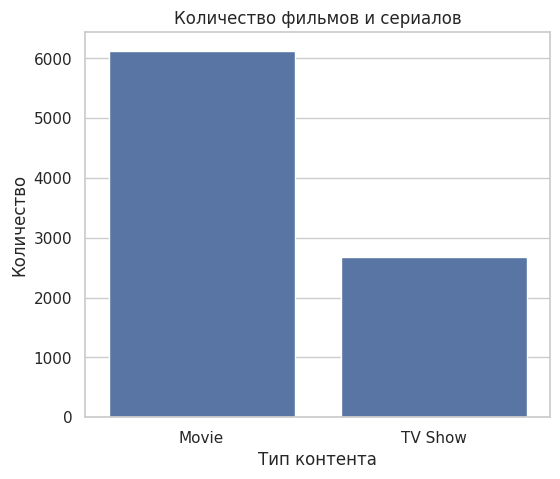

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(data=df_clean, x='type')

plt.title("Количество фильмов и сериалов")
plt.xlabel("Тип контента")
plt.ylabel("Количество")

plt.show()

### Вывод

Большую часть контента Netflix составляют фильмы, тогда как сериалов значительно меньше.

## 9.2 Распределение контента по годам выпуска

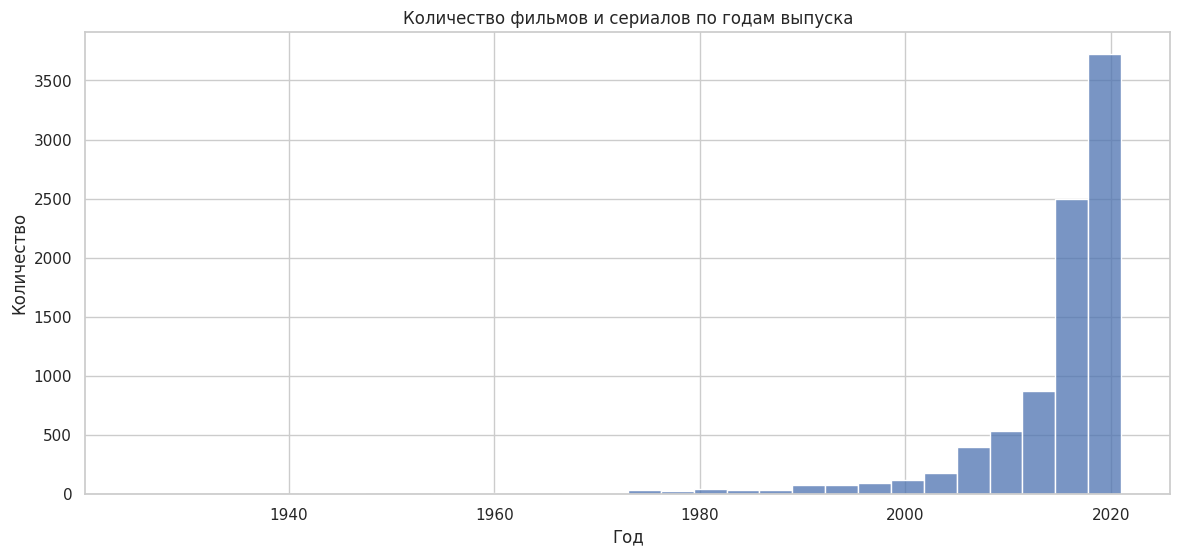

In [27]:
plt.figure(figsize=(14,6))

sns.histplot(df_clean['release_year'], bins=30)

plt.title("Количество фильмов и сериалов по годам выпуска")
plt.xlabel("Год")
plt.ylabel("Количество")

plt.show()

### Вывод

Основная часть контента была выпущена после 2000 года, что свидетельствует о преобладании современных фильмов и сериалов.

## 9.3 Топ-10 стран по количеству контента

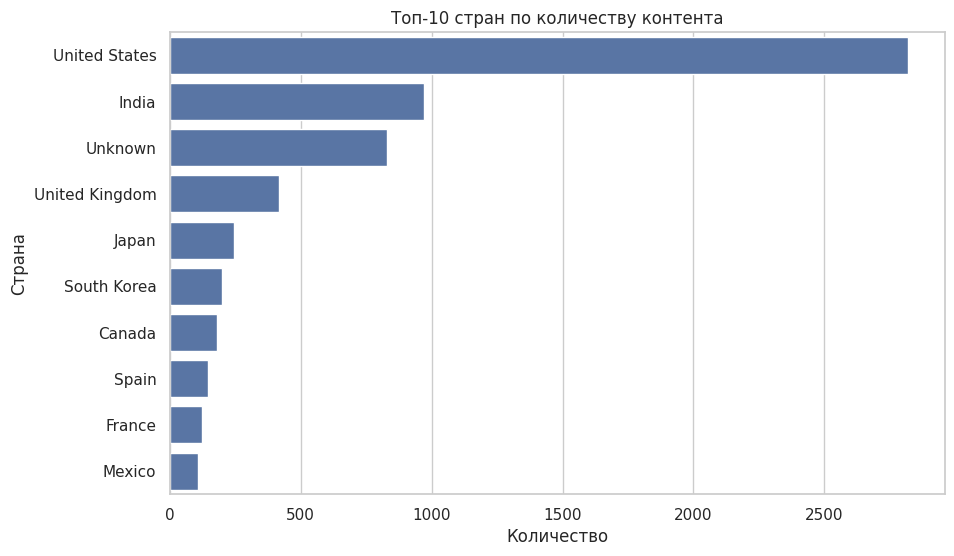

In [28]:
top_country = df_clean['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_country.values,
            y=top_country.index)

plt.title("Топ-10 стран по количеству контента")
plt.xlabel("Количество")
plt.ylabel("Страна")

plt.show()

### Вывод

Лидером по количеству произведенного контента являются США.

## 9.4 Наиболее популярные возрастные рейтинги

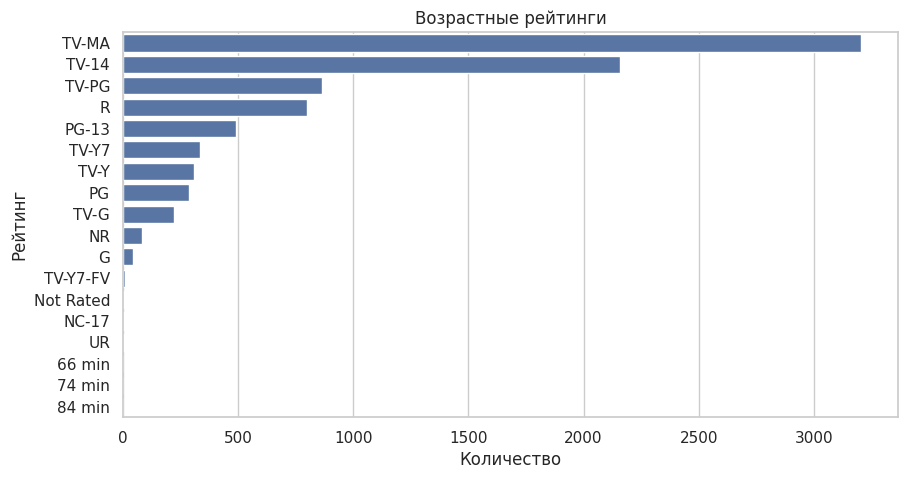

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    y='rating',
    order=df_clean['rating'].value_counts().index
)

plt.title("Возрастные рейтинги")
plt.xlabel("Количество")
plt.ylabel("Рейтинг")

plt.show()

### Вывод

Наиболее распространёнными являются рейтинги TV-MA и TV-14.

## 9.5 Тепловая карта пропусков

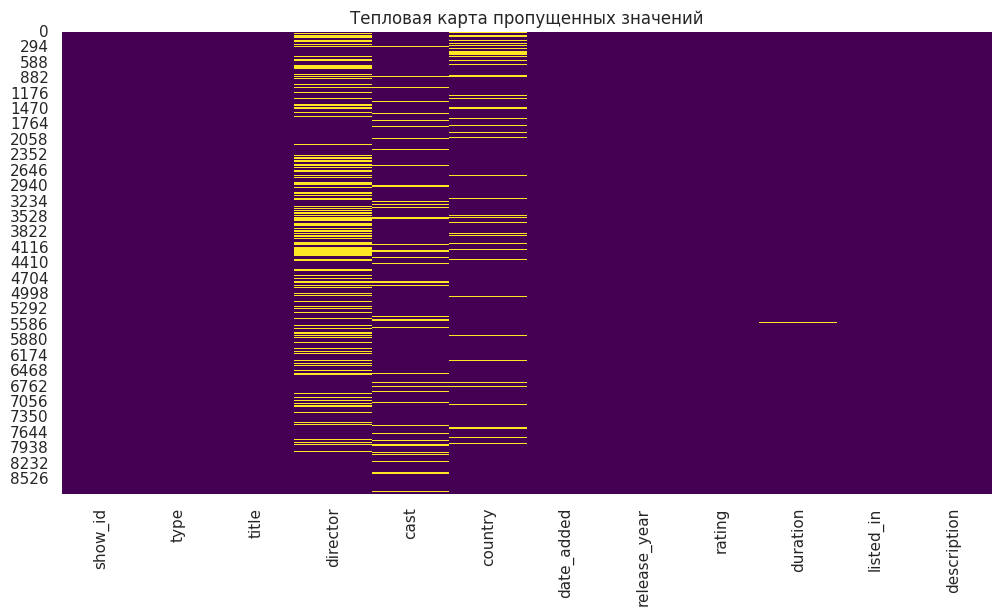

In [30]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Тепловая карта пропущенных значений")

plt.show()

### Вывод

Тепловая карта позволяет визуально определить признаки, содержащие пропущенные значения.

## 9.6 Динамика добавления контента на Netflix

Исследуем, как менялось количество добавленных фильмов и сериалов по годам.

In [37]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].astype(str).str.strip(),
    format='mixed',
    errors='coerce'
)

df_clean['year_added'] = df_clean['date_added'].dt.year

## 9.10 Топ-10 режиссеров

Построим график, показывающий режиссеров, которые чаще всего встречаются в датасете Netflix.

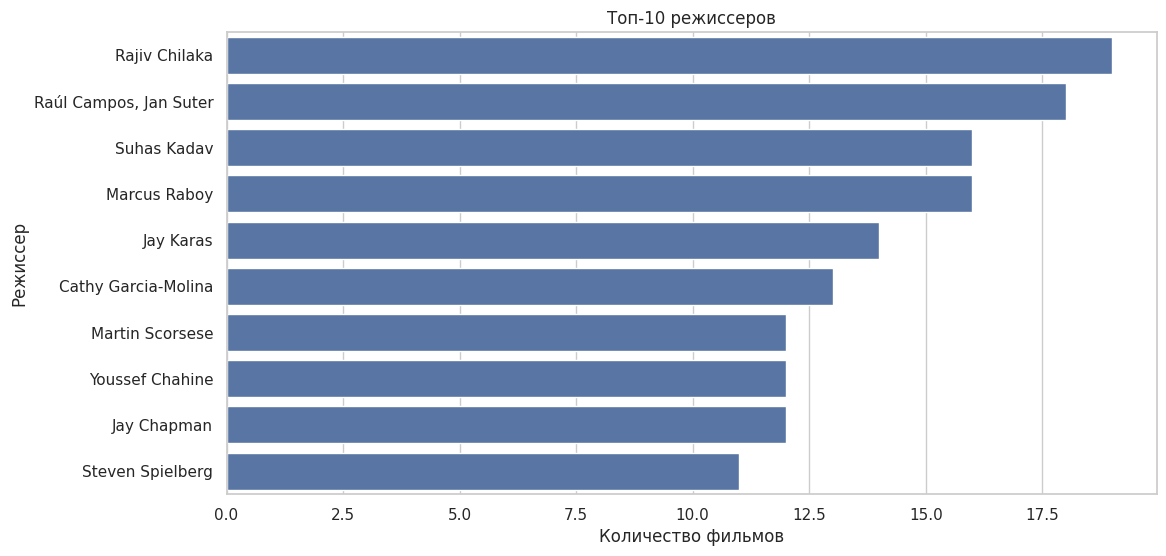

In [38]:
top_directors = (
    df_clean[df_clean['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Топ-10 режиссеров")
plt.xlabel("Количество фильмов")
plt.ylabel("Режиссер")

plt.show()

### Вывод

На графике представлены режиссеры, которые выпустили наибольшее количество фильмов и сериалов на платформе Netflix.

## 9.11 Распределение возрастных рейтингов по типу контента

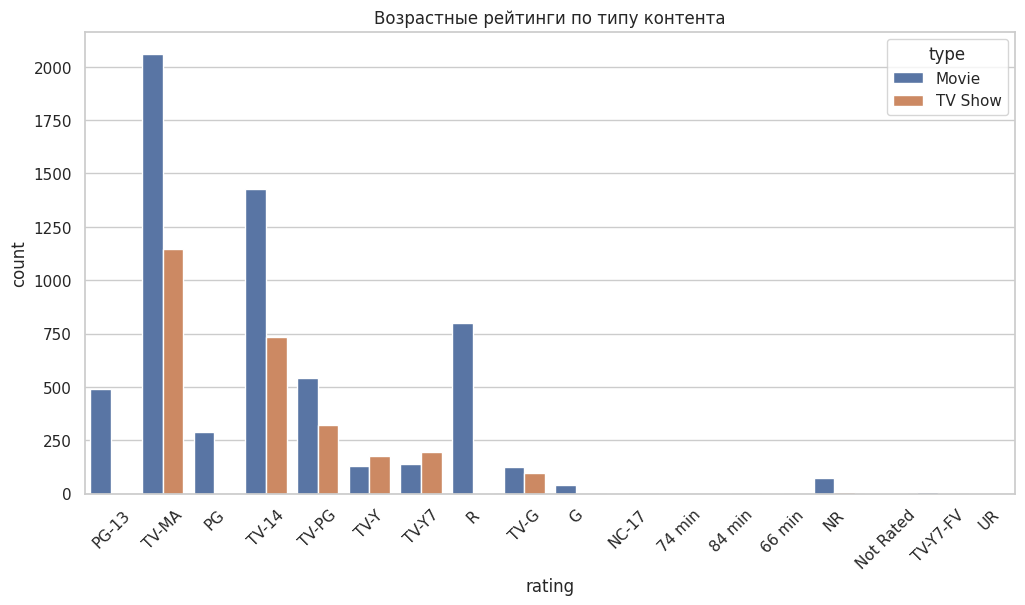

In [39]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    x='rating',
    hue='type'
)

plt.xticks(rotation=45)

plt.title("Возрастные рейтинги по типу контента")

plt.show()

### Вывод

Фильмы и сериалы распределены по различным возрастным категориям. Наиболее распространены рейтинги TV-MA и TV-14.

# Общий вывод по визуализации

В результате анализа были исследованы основные характеристики датасета:

- типы контента;
- годы выпуска;
- страны;
- жанры;
- возрастные рейтинги;
- продолжительность фильмов;
- наиболее популярные режиссеры.

Полученные результаты помогут на следующем этапе выполнить машинное обучение и создать интерактивный дашборд.

In [41]:
from google.colab import files

files.download("netflix_titles_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>